In [ ]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import navis
from datetime import datetime
from tqdm import tqdm
import random
import re
import trimesh

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import clear_output

***useful tutorial on meshparty and meshwork:***
https://tutorial.microns-explorer.org/quickstart_notebooks/00_skeletons.html

In [3]:
# ### CAVE AND CATMAID AUTH ####
# not required for current notebook

# #megalopta project id: 8
# #megalopta test project id: 25
# #megalopta flywire project id: 28

# path = 'path' # replace with your path to config file

# with open(path, 'r') as f:
#     conn_file = json.load(f)
# api_token = conn_file['api_token']
# http_user = conn_file['http_user']
# http_password = conn_file['http_password']
# server = conn_file['server']

# cat_client = pymaid.CatmaidInstance(server = server, 
#                                 api_token = api_token,
#                                 caching = True,
#                                 project_id = 8,
#                                 http_user = http_user,
#                                 http_password = http_password 
#                                 )


# client = caveclient.CAVEclient(server_address='https://global.connectomics.braininbrain.org')
# auth = client.auth

# #client.info.get_datastacks()
# client = caveclient.CAVEclient(datastack_name='megalopta_fb_eb_datastack')
# navis.patch_cloudvolume()
# vol = cv.CloudVolume('graphene://https://local.cave.braininbrain.org/segmentation/table/megalopta_FB_EB_v3', use_https=True, progress=False)

### import nametable

In [4]:
# to associate CAVE root ids with neuron identities
nametable = pd.read_csv('../../data/Megalopta_EB_preprint_FINAL - FBEB_EPG.csv')

nametable = nametable[['Catmaid name', 'Root ID', 'CATMAID skid']].rename(columns={'Catmaid name':'name', 'Root ID':'root_ids', 'CATMAID skid':'skid'})

nametable['skid'] = nametable['skid'].fillna(0).astype(float).astype(int)

# make sure to fill na
nametable['root_ids'] = nametable['root_ids'].fillna('').astype(str)

# convert each cell in 'root_ids' from a comma-separated string to a list of integers, ignoring empty strings
nametable['root_ids'] = nametable['root_ids'].apply(lambda x: [int(seg) for seg in x.split(',') if seg.strip()])

# remove empty values
nametable = nametable[nametable['root_ids'].apply(lambda x: len(x) > 0)].copy()

nametable = nametable[nametable['name'].str.contains(r"EPG_R8|EPG_L2")] # only include EPGs

print(nametable)

nametable_exploded = nametable.copy()
nametable_exploded = nametable_exploded.explode('root_ids')

epg_root_list = nametable_exploded['root_ids']
print()
print(epg_root_list)

           name              root_ids   skid
0  EPG_L2_55944  [576460753028086028]  55944
1  EPG_L2_55952  [576460752952978497]  55952
4  EPG_R8_56356  [576460753079329289]  56356
5  EPG_R8_56383  [576460753204982208]  56383
6  EPG_R8_55936  [576460753083932794]  55936
7  EPG_R8_64276  [576460753112188991]  64276

0    576460753028086028
1    576460752952978497
4    576460753079329289
5    576460753204982208
6    576460753083932794
7    576460753112188991
Name: root_ids, dtype: object


### import synapse table
- will be linked to neurons later on (this is work around while materialization engine is offline)

In [5]:
# import synapse table and generate random unique IDs for each synapse
# takes a min, probably a better way to do this...

syntable = pd.read_csv('../../data/megalopta_cx_syntable_19-04-26.csv')

syntable = syntable[syntable['roi'].str.contains(r'EB')]

for c in tqdm([c for c in syntable.columns if 'coords' in c or 'vox' in c]): 
    syntable[c] = syntable[c].apply(lambda s: tuple(map(int, s.strip('()').split(','))))

syntable = syntable[syntable['pre_skid'] != syntable['post_skid']] #remove autapses

syntable.head(5)

# Function to generate unique random connector IDs
def unique_id_generator(existing_ids: set, size: int = 7) -> str:
    """Creates a random unique string of digits of the specified length."""
    while True:
        first_digit = random.choice('123456789')  # Ensures the first digit is not '0'
        remaining_digits = ''.join(random.choice('0123456789') for _ in range(size - 1))
        new_id = first_digit + remaining_digits
        if new_id not in existing_ids:  # Check uniqueness
            existing_ids.add(new_id)
            return new_id

syntable['connector_id'] = None

# Set to track unique IDs
existing_ids = set(syntable['connector_id'].dropna())  # Include existing non-null IDs if any

# Apply unique ID generator
syntable['connector_id'] = syntable['connector_id'].apply(
    lambda x: unique_id_generator(existing_ids) if pd.isnull(x) else x
)

syntable["connector_id"] = syntable["connector_id"].astype(int)

syntable.head()

C:\Users\Marcel\AppData\Local\Temp\ipykernel_23876\536445619.py:4: DtypeWarning: Columns (2,3,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  syntable = pd.read_csv('../../data/megalopta_cx_syntable_19-04-26.csv')
0it [00:00, ?it/s]


,pre_skid,post_skid,pre_name,post_name,pre_coord,post_coord,roi,pre_root_ids,post_root_ids,pre_side,post_side,type_pre_col,type_post_col,type_pre,type_post,connector_id
0,NaN,NaN,NaN,NaN,"(19151, 15985, 1290)","(19126, 15985, 1291)",EB,576460753050011843,576460753050011843,NaN,NaN,NaN,NaN,NaN,NaN,1433493
1,NaN,NaN,NaN,NaN,"(19166, 15985, 1295)","(19150, 15980, 1297)",EB,576460753050011843,576460753050011843,NaN,NaN,NaN,NaN,NaN,NaN,9111901
2,NaN,NaN,NaN,NaN,"(19151, 15794, 1303)","(19160, 15816, 1303)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,NaN,NaN,7905153
3,NaN,NaN,NaN,NaN,"(19161, 15792, 1302)","(19138, 15808, 1302)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,NaN,NaN,7956124
4,NaN,NaN,NaN,NaN,"(19149, 15787, 1303)","(19163, 15797, 1303)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,NaN,NaN,2515968


# Skeletonize neuron mesh 
- uses pcg_skel package and downloads meshwork objects from CAVE and takes advantage of meshwork / meshparty functions. Meshwork objects maintain neuron skeleton / mesh / and annotations integrated together. In current note, this has already been done (code blocked out below) and swc skeletons are imported directly. 

### Use pcg_skel to download meshwork neurons, convert to navis tree neurons, snap synapses 

In [6]:
root_ids = []
for roots in nametable['root_ids']:
    root_ids.extend(roots)

root_ids

[576460753028086028,
 576460752952978497,
 576460753079329289,
 576460753204982208,
 576460753083932794,
 576460753112188991]

In [ ]:
# function used to skeletonize neuron from CAVE segmentation
# meshworks = []

# for root in root_ids:
#     s = pcg_skel.pcg_meshwork(root_id=root, client=client) #there's also function: pcg_skeleton one could try
#     print(f"downloaded skeleton for root_id: {root}")
#     meshworks.append(s)

100%|██████████████████████████████████████████████████| 1389/1389 [01:10<00:00, 25.28it/s]

In [454]:
# for mw in meshworks:
#     pcg_skel.features.add_volumetric_properties(mw, client=client)
#     pcg_skel.features.add_segment_properties(mw)
    
# NOTE: "effective node radius" can found here: s.anno.segment_properties['r_eff']

In [7]:
def r_eff_nm_per_skel_vertex(mw, agg="median"):
    # Segment properties table
    df = mw.anno.segment_properties.df.copy()

    # Map each row (mesh-indexed) to skeleton vertex index
    df["skel_index"] = mw.anno.segment_properties.mesh_index.to_skel_index_padded
    df = df[df["skel_index"] >= 0]

    # Aggregate r_eff per skeleton vertex
    if agg == "median":
        r = df.groupby("skel_index")["r_eff"].median()
    elif agg == "mean":
        r = df.groupby("skel_index")["r_eff"].mean()
    else:
        raise ValueError("agg must be 'median' or 'mean'")

    # Put into a dense vector aligned with skeleton vertex indices 0..n-1
    out = np.full(mw.skeleton.n_vertices, np.nan, dtype=float)
    sk = r.index.to_numpy(dtype=int)
    out[sk] = r.to_numpy()

    # Fill any missing entries conservatively (common for special/root nodes):
    # - if you prefer, replace with neighbour-averaging along the graph
    # - here we default to global median as a safe fallback
    missing = np.isnan(out)
    if missing.any():
        out[missing] = np.nanmedian(out)

    return out


In [9]:
# used to map neuron names from nametable to skeletonized CAVE neurons
# not needed for current notebook state

# id_to_name = {}

# for _, row in nametable.iterrows(): # for looking up neuron names
#     roots = row['root_ids']
#     if not isinstance(roots, list):
#         roots = [roots]
#     for r in roots:
#         id_to_name[r] = row['name']


# for mw in meshworks:
#     radius_nm = r_eff_nm_per_skel_vertex(mw, agg="median")

#     # Optional: compartment labels (0=undefined, 1=soma) - set root as soma
#     labels = np.zeros(mw.skeleton.n_vertices, dtype=int)
#     labels[int(mw.skeleton.root)] = 1
    
#     root_id = mw.seg_id
#     name = id_to_name.get(root_id, f"unknown_{root_id}")
    
#     mw.skeleton.export_to_swc(
#         filename=str(out_dir / f"{name}.swc"),
#         node_labels=labels,
#         radius=radius_nm,
#         xyz_scaling=1
#     )

In [10]:
# imoprt as navis TreeNeuron
swc_dir = Path('../../data/')
neurons = []

for fn in swc_dir.iterdir():
    if fn.suffix.lower() == '.swc':
        n = navis.read_swc(fn)
        n.name = fn.stem
        neurons.append(n)
        
neurons = navis.NeuronList(neurons)

name_to_skid = {}

for _, row in nametable.iterrows():
    name_to_skid[row['name']] = row['skid']

for n in neurons:
    n.id = name_to_skid.get(n.name, f"unknown_{n.name}")

In [11]:
# unable to merge these two fragments (EPG_R8_56383) due to unresolved CAVE issue (NoneType error)
# need to drop from list 

indices_to_remove = [4]
neurons = navis.NeuronList([n for i, n in enumerate(neurons) if i not in indices_to_remove])
neurons

,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin
0,navis.TreeNeuron,EPG_L2_55944,55944,975,None,87,101,2775573.50,[0],1 dimensionless,2026-09-04 18:53:55.149192,..\..\data\EPG_L2_55944.swc
1,navis.TreeNeuron,EPG_L2_55952,55952,1389,None,133,160,3776151.00,[0],1 dimensionless,2026-09-04 18:53:55.168369,..\..\data\EPG_L2_55952.swc
...,...,...,...,...,...,...,...,...,...,...,...,...
3,navis.TreeNeuron,EPG_R8_56356,56356,1357,None,116,141,3829983.50,[0],1 dimensionless,2026-09-04 18:53:55.204382,..\..\data\EPG_R8_56356.swc
4,navis.TreeNeuron,EPG_R8_64276,64276,903,None,77,92,2533844.75,[0],1 dimensionless,2026-09-04 18:53:55.238821,..\..\data\EPG_R8_64276.swc


(<Figure size 800x800 with 1 Axes>, <Axes: >)

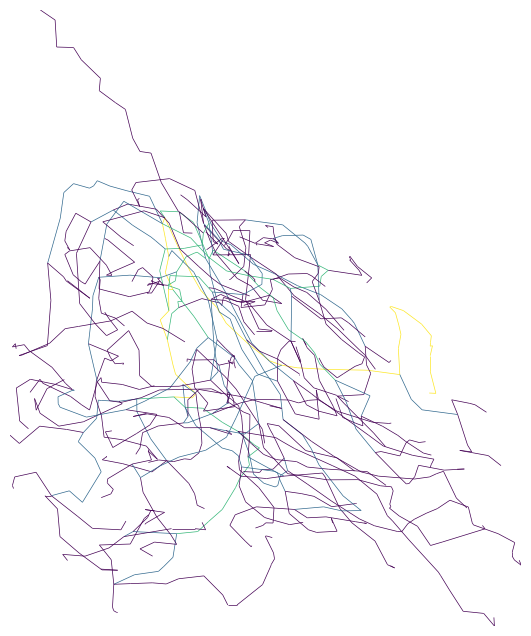

In [15]:
navis.plot2d(
    neurons[0], color_by="strahler_index", palette="viridis", view=("x", "-z"), method="2d"
)

## snap syanpses to closest node

In [16]:
# link 'connectors' (synapses) to nearest nodes on neuron skeleton
def parse_position(pos):
    if isinstance(pos, str):
        # Remove any enclosing brackets or parentheses
        pos = pos.strip("[]()")
        
        # Split on comma or whitespace
        parts = re.split(r'[,\s]+', pos.strip())
        
        try:
            return [int(p) for p in parts if p]
        except ValueError:
            return [np.nan, np.nan, np.nan]
    
    elif isinstance(pos, (list, tuple, np.ndarray)):
        return list(pos)
    
    else:
        return [np.nan, np.nan, np.nan]

sk_list = neurons.copy()

for n in sk_list:
    skid = int(n.id)
    cotable = syntable[(syntable['pre_skid'] == skid) | (syntable['post_skid'] == skid)]
        
    if cotable.empty:
        print('No connectors found for the following skid(s):')
        print(skid)
        print()
        continue        

    #────────────────────────────────────────────────────────
    # Process pre_matches
    pre_matches = cotable[cotable['pre_skid'] == skid].copy()
    pre_matches['type'] = 'pre'
    pre_matches['parsed_pos'] = pre_matches['pre_coord'].apply(parse_position)
    pre_matches[['x', 'y', 'z']] = pd.DataFrame(
        pre_matches['parsed_pos'].tolist(), index=pre_matches.index
    )

    #────────────────────────────────────────────────────────
    # Process post_matches
    post_matches = cotable[cotable['post_skid'] == skid].copy()
    post_matches['type'] = 'post'
    post_matches['parsed_pos'] = post_matches['post_coord'].apply(parse_position)
    post_matches[['x', 'y', 'z']] = pd.DataFrame(
        post_matches['parsed_pos'].tolist(), index=post_matches.index
    )

    #────────────────────────────────────────────────────────
    # Merge pre and post
    cotable = pd.concat([
        pre_matches[['type', 'x', 'y', 'z', 'connector_id']], 
        post_matches[['type', 'x', 'y', 'z', 'connector_id']]
    ], ignore_index=True)

    cotable.insert(0, "node_id", None)

    cotable[['x', 'y', 'z']] = cotable[['x', 'y', 'z']].astype(float)

    n.connectors = cotable.copy()

    cotable['type'] = pd.Categorical(cotable['type'], categories=['pre', 'post'])

    # Scale from voxels to nanometers
    n.connectors['x'] = n.connectors['x'] * 10
    n.connectors['y'] = n.connectors['y'] * 10
    n.connectors['z'] = n.connectors['z'] * 50

    n.connectors['locs'] = n.connectors[['x', 'y', 'z']].values.tolist()

    # Function to snap locs to nearest node
    def apply_snap(row):
        loc = row['locs']
        node_id, dist = n.snap(loc, to='nodes')
        return pd.Series([node_id, dist])

    n.connectors[['node_id', 'dist']] = n.connectors.apply(apply_snap, axis=1)

# final output:
sk_list


,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin
0,navis.TreeNeuron,EPG_L2_55944,55944,975,5227,87,101,2775573.50,[0],1 dimensionless,2026-09-04 18:53:55.149192,..\..\data\EPG_L2_55944.swc
1,navis.TreeNeuron,EPG_L2_55952,55952,1389,7341,133,160,3776151.00,[0],1 dimensionless,2026-09-04 18:53:55.168369,..\..\data\EPG_L2_55952.swc
...,...,...,...,...,...,...,...,...,...,...,...,...
3,navis.TreeNeuron,EPG_R8_56356,56356,1357,9450,116,141,3829983.50,[0],1 dimensionless,2026-09-04 18:53:55.204382,..\..\data\EPG_R8_56356.swc
4,navis.TreeNeuron,EPG_R8_64276,64276,903,5397,77,92,2533844.75,[0],1 dimensionless,2026-09-04 18:53:55.238821,..\..\data\EPG_R8_64276.swc


### prune neuron to EB mesh bbox

In [21]:
# eb_m = pymaid.get_volume(['EB'], remote_instance=cat_client)
# navis.write_mesh(eb_m, '../../data/eb_ed_m.stl')

In [17]:
# import EB mesh and create bounding box
# note: somehow cave neuron coordinates already match CATMAID coordinates, no conversion needed

eb_m = navis.read_mesh('../../data/eb_ed_m.stl', output='volume')

'''create bbox from EB mesh'''
bbox = eb_m.bbox
# Extract min and max points using neuron bbox
x_min, x_max = bbox[0][0], bbox[1][0]
y_min, y_max = bbox[0][1], bbox[1][1]
z_min, z_max = bbox[0][2], bbox[1][2]

# Generate 8 corners of the bounding box
bbox_corners = np.array([
    [x_min, y_min, z_min],
    [x_min, y_min, z_max],
    [x_min, y_max, z_min],
    [x_min, y_max, z_max],
    [x_max, y_min, z_min],
    [x_max, y_min, z_max],
    [x_max, y_max, z_min],
    [x_max, y_max, z_max]
])

# Create a Trimesh box from the corners
mesh_bbox = trimesh.convex.convex_hull(bbox_corners)

mesh_bbox

<trimesh.Trimesh(vertices.shape=(8, 3), faces.shape=(12, 3))>

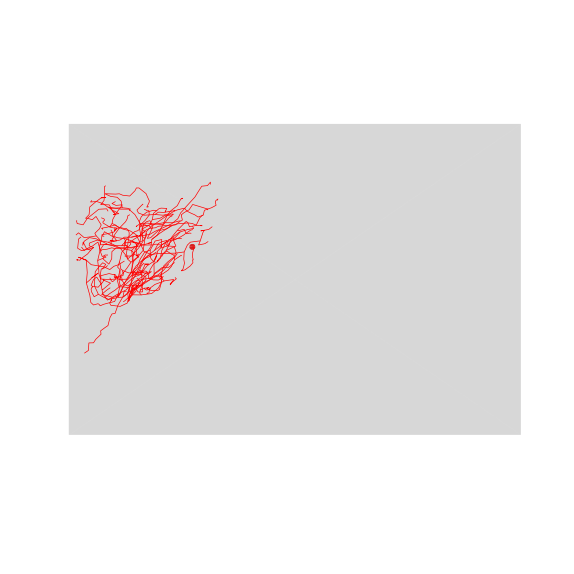

In [18]:
# check mesh coordinate line up with skeleton
fig=navis.plot2d([sk_list[0], mesh_bbox], color=['red', (0.3,0.3,0.3,0.1)])

In [44]:
# 0, 1 = y min only
# 2, 3, 4, 5, 6 = min x
# 3, 4 same neuron...
print('for EPG_L2, root should be min y')
print('for EPG_R8, root should be min x')

# sk_list = skel_list.copy()
nRooted_list = []

# Define the L2 EPGs
l2_epg = ['EPG_L2_55944', 'EPG_L2_55952'] #EPG_L2_55952

for n in sk_list:
    nRooted = n.copy()
    nRooted.nodes['radius'] = nRooted.nodes['radius'].replace(0, 50)  # avoid zero-radius nodes

    if len(nRooted.root) == 1:
        if nRooted.name in l2_epg:
            # Use min y for EPG_L2s
            minY = nRooted.nodes.loc[nRooted.nodes['y'].idxmin()]
            node_id = minY['node_id']
            axis = 'y'
        else:
            # Use min x otherwise
            minX = nRooted.nodes.loc[nRooted.nodes['x'].idxmin()]
            node_id = minX['node_id']
            axis = 'x'

        nRooted = navis.reroot_skeleton(nRooted, node_id)
        nRooted.soma = nRooted.root
        nRooted.soma_radius = 2000
        print(f'{nRooted.name} root set to min {axis}')
        print(f'new root: {nRooted.root}; new soma: {nRooted.soma}, resized to {nRooted.soma_radius}')

        # recalculate strahler index for plotting
        navis.strahler_index(nRooted)

        print(f'{nRooted.name} root set to min {axis}')
        print(
            f'new root: {nRooted.root}; '
            f'new soma: {nRooted.soma}'
        )
    else:
        print(f'{nRooted.name} has multiple roots, soma not set')

    nRooted_list.append(nRooted)

nRooted_list = navis.NeuronList(nRooted_list)

for EPG_L2, root should be min y
for EPG_R8, root should be min x
EPG_L2_55944 root set to min y
new root: [850]; new soma: [850], resized to 2000
EPG_L2_55944 root set to min y
new root: [850]; new soma: [850]
EPG_L2_55952 root set to min y
new root: [1288]; new soma: [1288], resized to 2000
EPG_L2_55952 root set to min y
new root: [1288]; new soma: [1288]
EPG_R8_55936 root set to min x
new root: [699]; new soma: [699], resized to 2000
EPG_R8_55936 root set to min x
new root: [699]; new soma: [699]
EPG_R8_56356 root set to min x
new root: [740]; new soma: [740], resized to 2000
EPG_R8_56356 root set to min x
new root: [740]; new soma: [740]
EPG_R8_64276 root set to min x
new root: [826]; new soma: [826], resized to 2000
EPG_R8_64276 root set to min x
new root: [826]; new soma: [826]


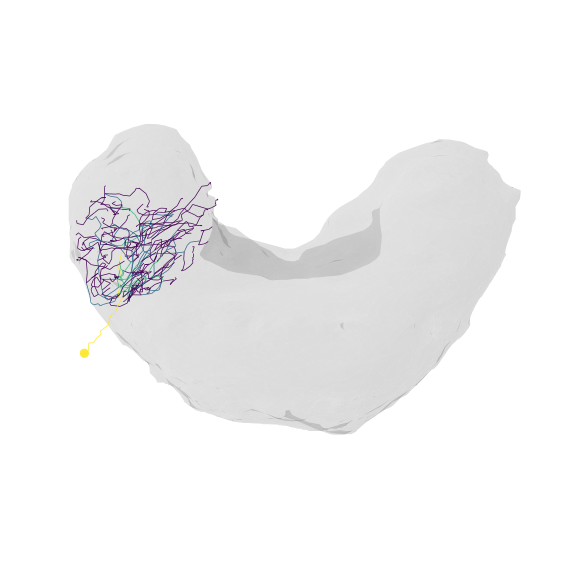

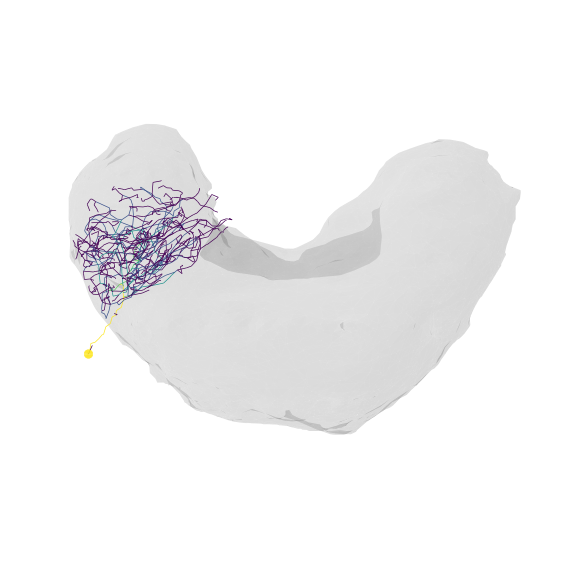

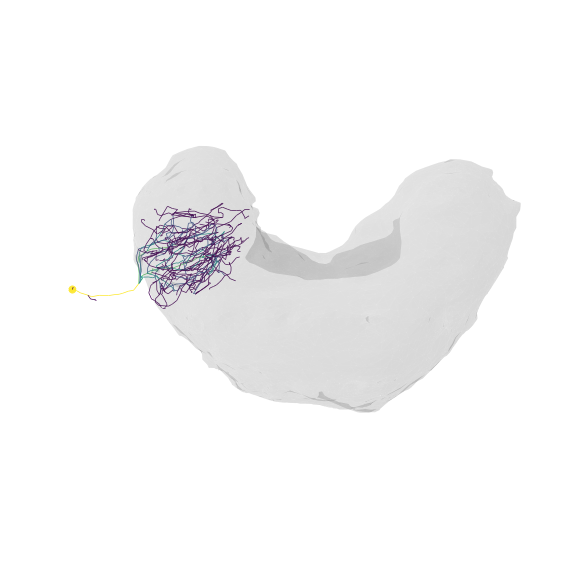

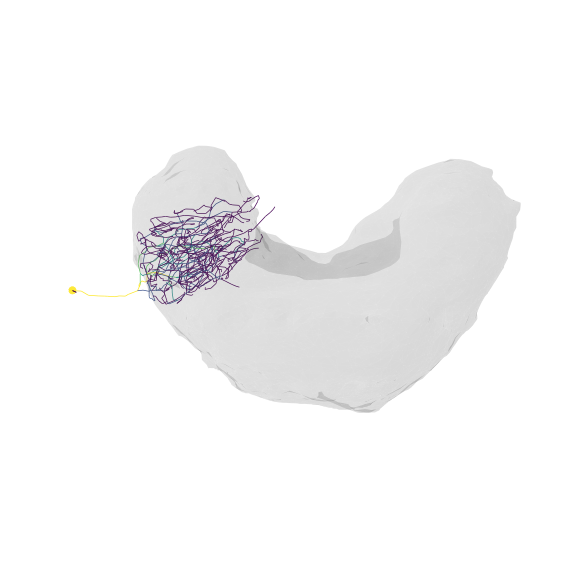

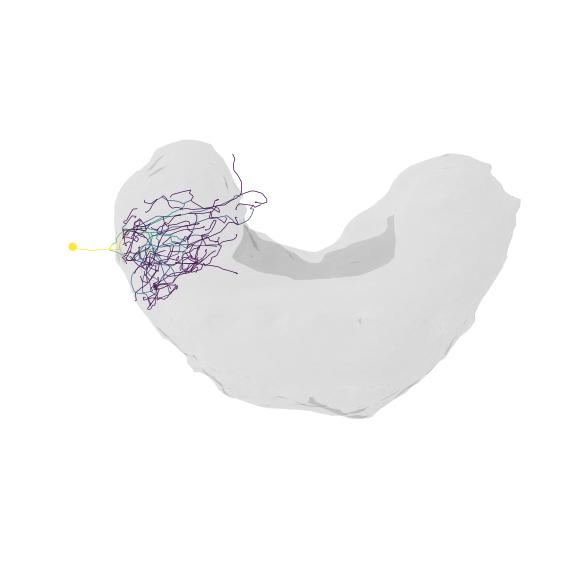

In [48]:
# Check root is correct for all EPGs (should be yellow using below strahler_index viridis palette)
eb_m.color = (120, 120, 120, 0.1)
for n in nRooted_list:
    fig=navis.plot2d([n, eb_m], soma=True, color_by="strahler_index", palette="viridis", color=(0.3,0.3,0.3,0.1), alpha=1)

***Note on column names: 
dist = connector → nearest skeleton node, through 3D space (can be thought of as error)
distRoot = nearest skeleton node → root, following the neuronal arbor (aka "geodesic distance to root)"***

In [49]:
# calculate geodesic distance to root
for n in nRooted_list: 
    distRoot = navis.dist_to_root(n, weight='weight')
    n.connectors['distRoot'] = n.connectors['node_id'].map(distRoot)

nRooted_list[0].connectors # should see column distRoot

,node_id,type,x,y,z,connector_id,locs,dist,distRoot
0,847.0,pre,226810.0,169950.0,145700.0,9077831,"[226810.0, 169950.0, 145700.0]",1690.502884,9972.050026
1,847.0,pre,226920.0,170260.0,145850.0,9264311,"[226920.0, 170260.0, 145850.0]",1957.779354,9972.050026
2,842.0,pre,233210.0,180210.0,154200.0,6129467,"[233210.0, 180210.0, 154200.0]",1125.788612,26683.799034
3,841.0,pre,234830.0,182930.0,156650.0,8688340,"[234830.0, 182930.0, 156650.0]",1837.688766,30764.485251
4,841.0,pre,234880.0,182900.0,156650.0,5098852,"[234880.0, 182900.0, 156650.0]",1876.938997,30764.485251
...,...,...,...,...,...,...,...,...,...
5222,131.0,post,280110.0,259480.0,206550.0,4228575,"[280110.0, 259480.0, 206550.0]",1748.084666,186646.272645
5223,131.0,post,281200.0,260300.0,206800.0,3077787,"[281200.0, 260300.0, 206800.0]",2454.791233,186646.272645
5224,131.0,post,280190.0,257840.0,207400.0,3596268,"[280190.0, 257840.0, 207400.0]",377.491722,186646.272645
5225,131.0,post,280410.0,257510.0,207750.0,1133087,"[280410.0, 257510.0, 207750.0]",608.194048,186646.272645


### generate geodesic matrix and eDist

In [50]:
def add_edist_to_connectors(n):
    n = n.copy()
    nodes = n.nodes.copy()
    connectors = n.connectors.copy()

    cols = ["node_id", "parent_id", "x", "y", "z", "radius"]
    nodes = nodes[cols].copy()

    parents = nodes[["node_id", "x", "y", "z"]].rename(columns={
        "node_id": "parent_id",
        "x": "px",
        "y": "py",
        "z": "pz"
    })

    nodes = nodes.merge(parents, on="parent_id", how="left")

    # Euclidean edge length to parent
    nodes["seg_len"] = np.sqrt(
        (nodes["x"] - nodes["px"])**2 +
        (nodes["y"] - nodes["py"])**2 +
        (nodes["z"] - nodes["pz"])**2
    )
    nodes.loc[nodes["parent_id"] == -1, "seg_len"] = 0.0

    # If radius = half-width, then width = 2 * radius
    # Your paper says lambda is based on width of the edge.
    nodes["length_constant"] = np.sqrt(nodes["radius"] / 2)
    # equivalent to sqrt((2*radius)/4)

    # electrotonic distance of each edge = edge length / length constant
    nodes["eDist_segment"] = np.where(
        nodes["seg_len"] > 0,
        nodes["seg_len"] / nodes["length_constant"],
        0.0
    )

    parent_dict = dict(zip(nodes["node_id"], nodes["parent_id"]))
    seg_edist_dict = dict(zip(nodes["node_id"], nodes["eDist_segment"]))

    dist_to_root = {}

    def compute_dist_to_root_iter(node_id):
        path = []
        current = node_id

        while current not in dist_to_root:
            path.append(current)
            parent = parent_dict.get(current, -1)
            if parent == -1:
                dist_to_root[current] = 0.0
                break
            current = parent

        while path:
            child = path.pop()
            parent = parent_dict.get(child, -1)
            if parent == -1:
                dist_to_root[child] = 0.0
            else:
                dist_to_root[child] = dist_to_root[parent] + seg_edist_dict.get(child, 0.0)

        return dist_to_root[node_id]

    connectors["eDist"] = connectors["node_id"].map(compute_dist_to_root_iter)

    emin = connectors["eDist"].min()
    emax = connectors["eDist"].max()
    if emax > emin:
        connectors["normEDist"] = (connectors["eDist"] - emin) / (emax - emin)
    else:
        connectors["normEDist"] = 0.0

    n.connectors = connectors
    return n


# Process all neurons 
nRooted_list = [add_edist_to_connectors(n) for n in nRooted_list]

In [51]:
nRooted_list[0].connectors

,node_id,type,x,y,z,connector_id,locs,dist,distRoot,eDist,normEDist
0,847.0,pre,226810.0,169950.0,145700.0,9077831,"[226810.0, 169950.0, 145700.0]",1690.502884,9972.050026,420.821899,0.035763
1,847.0,pre,226920.0,170260.0,145850.0,9264311,"[226920.0, 170260.0, 145850.0]",1957.779354,9972.050026,420.821899,0.035763
2,842.0,pre,233210.0,180210.0,154200.0,6129467,"[233210.0, 180210.0, 154200.0]",1125.788612,26683.799034,1126.060043,0.095696
3,841.0,pre,234830.0,182930.0,156650.0,8688340,"[234830.0, 182930.0, 156650.0]",1837.688766,30764.485251,1298.265579,0.110331
4,841.0,pre,234880.0,182900.0,156650.0,5098852,"[234880.0, 182900.0, 156650.0]",1876.938997,30764.485251,1298.265579,0.110331
...,...,...,...,...,...,...,...,...,...,...,...
5222,131.0,post,280110.0,259480.0,206550.0,4228575,"[280110.0, 259480.0, 206550.0]",1748.084666,186646.272645,10408.581160,0.884555
5223,131.0,post,281200.0,260300.0,206800.0,3077787,"[281200.0, 260300.0, 206800.0]",2454.791233,186646.272645,10408.581160,0.884555
5224,131.0,post,280190.0,257840.0,207400.0,3596268,"[280190.0, 257840.0, 207400.0]",377.491722,186646.272645,10408.581160,0.884555
5225,131.0,post,280410.0,257510.0,207750.0,1133087,"[280410.0, 257510.0, 207750.0]",608.194048,186646.272645,10408.581160,0.884555


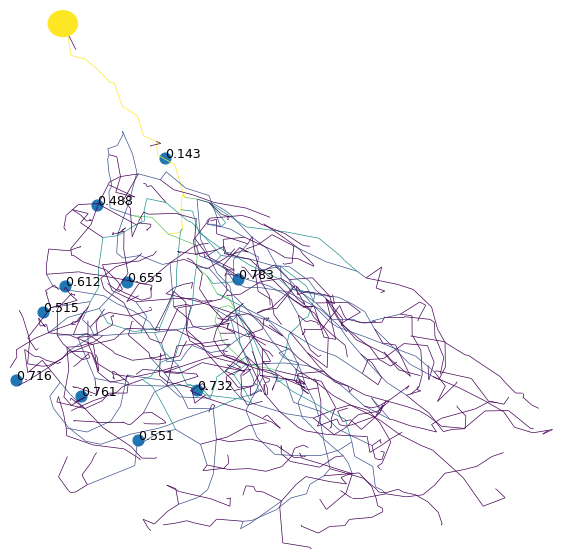

In [56]:
# verify this worked by randomly plotting some connectors alongisde their metrics

# choose neuron
idx = 1

# choose view
view = ("x", "-z") 

n = nRooted_list[idx]

# choose 5 random connectors
sample = n.connectors.sample(10, random_state=5).copy()

def project_coords(df, view):
    def get_axis(v):
        if v.startswith("-"):
            return -df[v[1:]].values
        else:
            return df[v].values

    return get_axis(view[0]), get_axis(view[1])

fig, ax = plt.subplots(figsize=(7, 7))
navis.plot2d(n, ax=ax, color_by="strahler_index", palette="viridis", method="2d", view=view, color="lightgray")

x, y = project_coords(sample, view)

ax.scatter(x, y, s=60)

for xi, yi, (_, row) in zip(x, y, sample.iterrows()):
    ax.text(xi, yi, f"{row['normEDist']:.3f}", fontsize=9)

plt.show()

In [57]:
# save connector table withe elctrotonic distance measurements to save time later
for n in nRooted_list:
    conntable = n.connectors
    conntable.to_csv(f'../../data/{n.name}_conntable_edc.csv') 


# Plot

In [58]:
color_dict = {
    'PEN_a': '#EEA700',
    'PEN_b': '#63BCFA',
    'LAL': '#CC655B',
    'LBU': '#51C9CB',
    'MBUv': "#FFA500",
    'MBUd': '#9355E1',
    'EPG': '#34B887',
    'PEG': '#EF506C'
}

In [59]:
# Create a directory to save the plots
save_dir = os.path.join(os.getcwd(), '../../results/plots')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
else:
    print(f"Directory already exists: {save_dir}")

# Get today's date for the filenames
today = datetime.now().strftime('%d-%m-%y')

plt.rcParams['pdf.fonttype'] = 'truetype'

Directory already exists: D:\Github\codeocean_codeReview\capsule-7474392\code\analysis\plots


### normalized normEDist CDF plot (all neurons)

In [60]:
nRooted_list[0].connectors.columns

Index(['node_id', 'type', 'x', 'y', 'z', 'connector_id', 'locs', 'dist',
       'distRoot', 'eDist', 'normEDist'],
      dtype='object')

In [61]:
# add partner names to connector tables using syntable
# remove pre (only interested in inputs to EPGs, not in EPG outputs to other neurons)
connector_tables = []

for n in nRooted_list:
    conn = n.connectors.copy()

    # Keep only inputs
    conn = conn[~conn['type'].str.contains("pre", na=False)].copy()

    # Add partner names
    conn['partner_name'] = conn['connector_id'].map(
        syntable.drop_duplicates('connector_id')
                .set_index('connector_id')['type_pre']
    )

    # Remove ExR
    conn = conn[
        ~conn['partner_name'].str.contains('ExR', na=False)
    ].copy()

    connector_tables.append(conn)

# Concatenate all neurons into one large table
n_conn = pd.concat(connector_tables, ignore_index=True)

n_conn.head()

,node_id,type,x,y,z,connector_id,locs,dist,distRoot,eDist,normEDist,partner_name
0,850.0,post,223480.0,163980.0,140350.0,1591673,"[223480.0, 163980.0, 140350.0]",2357.731961,0.000000,0.000000,0.000000,NaN
1,849.0,post,224920.0,167820.0,143150.0,9731153,"[224920.0, 167820.0, 143150.0]",2006.015952,4050.925820,170.949631,0.014528,NaN
2,849.0,post,224970.0,167820.0,143200.0,8309044,"[224970.0, 167820.0, 143200.0]",2046.484791,4050.925820,170.949631,0.014528,NaN
3,848.0,post,223000.0,166090.0,145500.0,1245779,"[223000.0, 166090.0, 145500.0]",2193.285207,7794.987785,328.949570,0.027955,NaN
4,848.0,post,223070.0,166110.0,145600.0,8771701,"[223070.0, 166110.0, 145600.0]",2120.047169,7794.987785,328.949570,0.027955,NaN


In [62]:
core = n_conn[n_conn['partner_name'].str.contains(r'EPG|PEG|PEN_a|PEN_b', na=False)]
er = n_conn[~n_conn['partner_name'].str.contains(r'EPG|PEG|PEN_a|PEN_b', na=False)]

Plot saved: D:\Github\codeocean_codeReview\capsule-7474392\code\analysis\plots\CORE_averaged_R8-L2_cdf_normEDist_04-09-26.pdf


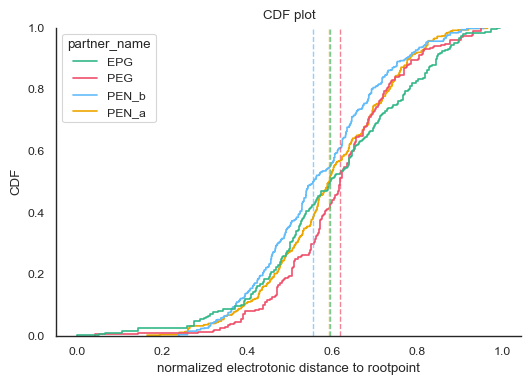

In [64]:
# normEDist plot for core neurons
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = core.groupby('partner_name')['normEDist'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=core,
    x="normEDist",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("normalized electrotonic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"CORE_averaged_R8-L2_cdf_normEDist_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()

Plot saved: D:\Github\codeocean_codeReview\capsule-7474392\code\analysis\plots\ER_averaged_R8-L2_cdf_normEDist_04-09-26.pdf


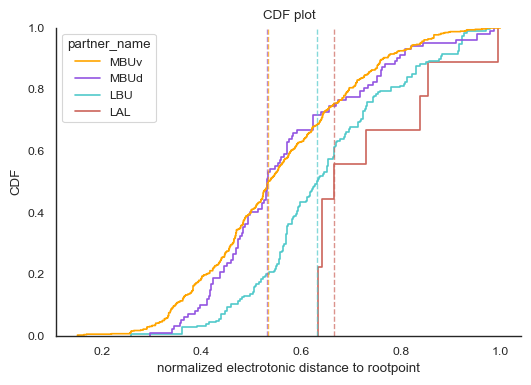

In [65]:
# normEDist plot for ER neurons
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = er.groupby('partner_name')['normEDist'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=er,
    x="normEDist",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("normalized electrotonic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"ER_averaged_R8-L2_cdf_normEDist_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()

### geodesic distance to root point cdf plots

Plot saved: D:\Github\codeocean_codeReview\capsule-7474392\code\analysis\plots\CORE_averaged_R8-L2_cdf_geodesic_distance_04-09-26.pdf


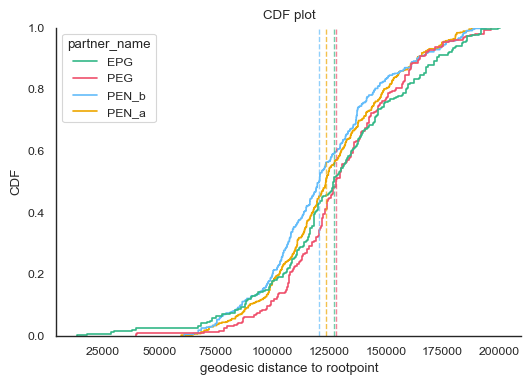

In [66]:
# geodesic distance to root plot for core neurons
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = core.groupby('partner_name')['distRoot'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=core,
    x="distRoot",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("geodesic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"CORE_averaged_R8-L2_cdf_geodesic_distance_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()

Plot saved: D:\Github\codeocean_codeReview\capsule-7474392\code\analysis\plots\ER_averaged_R8-L2_cdf_geodesic_distance_04-09-26.pdf


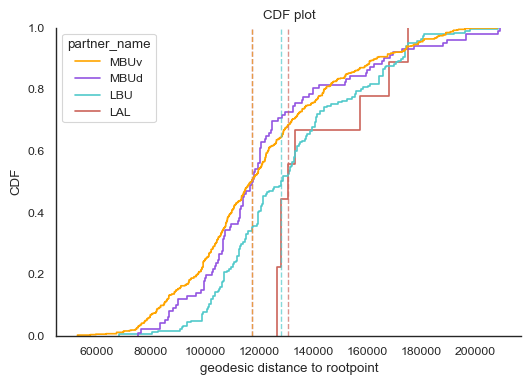

In [67]:
# geodesic distance to root plot for ER neurons
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = er.groupby('partner_name')['distRoot'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=er,
    x="distRoot",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("geodesic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"ER_averaged_R8-L2_cdf_geodesic_distance_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()